# LC change percentage data and plots - August 2026

In [ ]:
# Install required packages
import pandas as pd
from pathlib import Path
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [2]:
# Load LC change data
baseline = pd.read_csv("../Data/LULC/LC_area_change/LC_baseline.txt", sep="\\t")
m = pd.read_csv("../Data/LULC/LC_area_change/LC_M.txt", sep="\\t")
a1 = pd.read_csv("../Data/LULC/LC_area_change/LC_A1.txt", sep="\\t")
a2 = pd.read_csv("../Data/LULC/LC_area_change/LC_A2.txt", sep="\\t")
c = pd.read_csv("../Data/LULC/LC_area_change/LC_C.txt", sep="\\t")

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_59198/3962074363.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  baseline = pd.read_csv("../Data/LULC/LC_area_change/LC_baseline.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_59198/3962074363.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  m = pd.read_csv("../Data/LULC/LC_area_change/LC_M.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_59198/3962074363.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 

In [4]:
# Define colours to match LC classes from QGIS map
LC_colours = {
    "Grass": "#bbed89",
    "NonNativeConifers": "#0b7319d7",
    "Marshes": "#7e5c3af1",
    "MixedForest": "#63c6abd6",
    "Shrubs": "#f6f367ba",
    "Arable": "#ff9900",
    "Urban": "#cf0606c4",
    "Deciduous": "#55DB2C",
    "Water": "#049bff",
    "NativeConifers": "#c21eaebe",
}


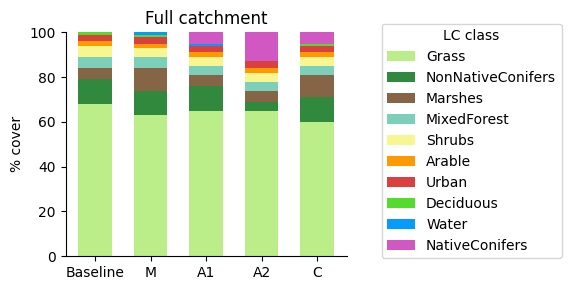

In [ ]:
# Plot stacked bar chart for full catchment
area = "Full"
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

lc_long = lc_data.melt(
    id_vars=["LC", "scenario"],
    value_vars=[area],
    var_name="area",
    value_name="percent",
)

lc_classes = lc_long["LC"].unique()
fig, ax = plt.subplots(figsize=(6, 3))

bottom = np.zeros(len(scenarios))
x = np.arange(len(scenarios))

for lc_class in lc_classes:
    class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
    values = class_df.reindex(scenarios).fillna(0).values
    colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
    ax.bar(
        x,
        values,
        0.6,
        bottom=bottom,
        label=lc_class,
        color=colour,
    )
    bottom += values

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Full catchment")
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("% cover")
ax.set_ylim(0, 100)
#ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="LC class", bbox_to_anchor=(1.1, 1.07), loc="upper left")

plt.tight_layout()
plt.show()


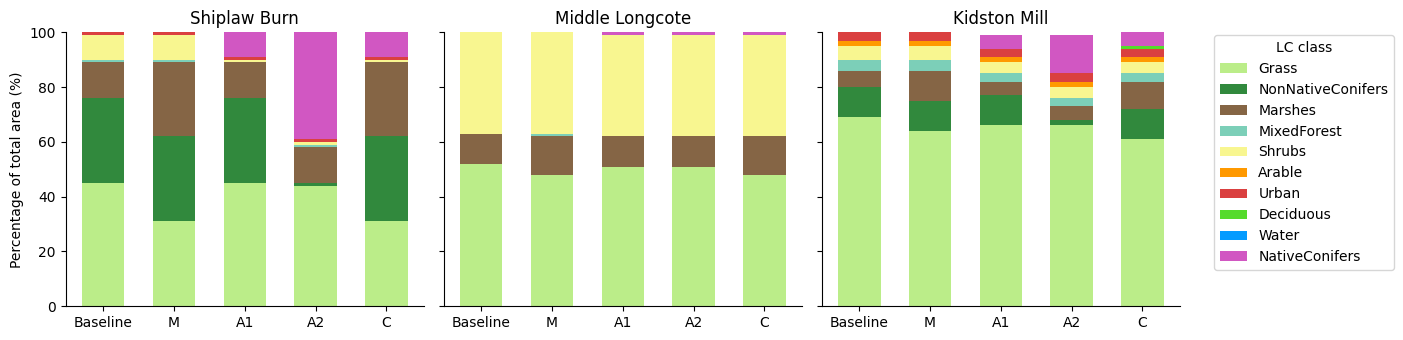

In [8]:
# Panel version for LC scenarios

# First combined scenarios into one dataframe
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

# Areas to plot
areas = {
    "SB": "Shiplaw Burn",
    "ML": "Middle Longcote",
    "KM": "Kidston Mill",
}

lc_classes = lc_data["LC"].unique()
x = np.arange(len(scenarios))

fig, axes = plt.subplots(1, len(areas), figsize=(4 * len(areas), 3.5), sharey=True)

for ax, (area, title) in zip(axes, areas.items()):
    lc_long = lc_data.melt(
        id_vars=["LC", "scenario"],
        value_vars=[area],
        var_name="area",
        value_name="percent",
    )

    bottom = np.zeros(len(scenarios))

    for lc_class in lc_classes:
        class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
        values = class_df.reindex(scenarios).fillna(0).values
        colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
        ax.bar(
            x,
            values,
            0.6,
            bottom=bottom,
            label=lc_class,
            color=colour,
        )
        bottom += values

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Percentage of total area (%)")

# Shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="LC class",
    bbox_to_anchor=(1.01, 0.55),
    loc="center left",
)

plt.tight_layout()

plt.savefig("../Results/Figure_41.png", dpi=400, bbox_inches="tight")
plt.show()